# Viz — Paper Figures

Reads CSV from `results/<DATE_FOLDER>/`.
Figures are saved to the same date folder as PDF. **Edit Cell 1 to set paths and style.**

**Metrics used in the paper:**
- **Utility** — ROC-AUC, F1 Score
- **Privacy** — MIA-AUC (forgotten EVCS; closer to 0.5 = stronger forgetting)
- **Efficiency** — unlearning time, peak memory

In [1]:
# Cell 1 — Config (edit here) — ITSG paper figures
# ============================================================
DATE_FOLDER = '2026-06-19_17'   # ← change to your results folder name
BUS_SYSTEM  = '123bus'           
TAG         = 'raw'              # raw feature mode -> {bus}_raw_raw.csv

# Style overrides — passed to apply_style(); see src/visualization.py STYLE dict
STYLE_OVERRIDES = {
    # Font — Times New Roman for all text
    'font_family':   'Times New Roman',
    'fs_label':      26,
    'fs_tick':       20,
    'fs_legend':     20,
    'fs_subtitle':   22,
    'fs_annotation': 18,

    # Colors — 5 methods (Original, GDGU, GIF, IDEA, Retrain)
    'colors': {
        'Original':  "#C7CADE",
        'GDGU':      "#F7AC53",
        'GIF':       "#52AADC",
        'IDEA':      "#EC6E66",
        'Retrain':   "#76BC79",
    },
    'markers': {
        'Original':  'o',
        'GDGU':      's',
        'GIF':       'D',
        'IDEA':      'P',
        'Retrain':   '^',
    },
    'ideal_line_color': 'red',
    'grid_alpha':       0.3,
    'bar_alpha':        0.85,
    'bar_edge_color':   'black',
    'bar_edge_width':   0.5,
    'fill_alpha':       0.15,

    # Save
    'save_fmt': 'pdf',
    'save_dpi': 300,
}

In [2]:
# Cell 2 — Setup
import sys, json
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.visualization import (apply_style, load_results, plot_all_v6,
                                plot_metric_bars, plot_metric_lines,
                                plot_per_evcs_roc, plot_mia_auc,
                                plot_mia_forget, plot_mia_retain, plot_mia_metric,
                                plot_f1_vs_mia, plot_gu_comparison, plot_time_comparison,
                                plot_memory_usage)

%load_ext autoreload
%autoreload 2

apply_style(STYLE_OVERRIDES)

RESULTS_DIR = PROJECT_ROOT / 'results' / DATE_FOLDER
df, scenarios, backbones = load_results(str(RESULTS_DIR), BUS_SYSTEM, tag=TAG)

# Show metadata from epoch logs if available
_prefix = BUS_SYSTEM if TAG is None else f'{BUS_SYSTEM}_{TAG}'
log_path = RESULTS_DIR / f'{_prefix}_epoch_logs.json'
if log_path.exists():
    with open(log_path) as f:
        meta = json.load(f).get('_metadata', {})
    print(f"\nTimestamp : {meta.get('timestamp', 'N/A')}")
    print(f"Device   : {meta.get('device', 'N/A')}")
    d = meta.get('data', {})
    print(f"Graphs={d.get('n_graphs')}, Nodes={d.get('n_nodes')}, "
          f"Features={d.get('n_feat')}, EVCS={d.get('n_evcs')}")
    for name, n_params in meta.get('model_params', {}).items():
        print(f"  {name}: {n_params:,} params")

Loaded 750 rows from /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-06-19_17/123bus_raw_raw.csv
  Backbones : ['GAT', 'GCN', 'GIN']
  Scenarios : ['S1', 'S2', 'S3', 'S4', 'S5']
  Methods   : ['GDGU', 'GIF', 'IDEA', 'Original', 'Retrain']

Timestamp : 2026-06-20 08:01:07
Device   : cuda:0
Graphs=4000, Nodes=132, Features=288, EVCS=5
  GAT: 661,893 params
  GCN: 141,189 params
  GIN: 190,725 params


## Individual figures (ITSG paper)

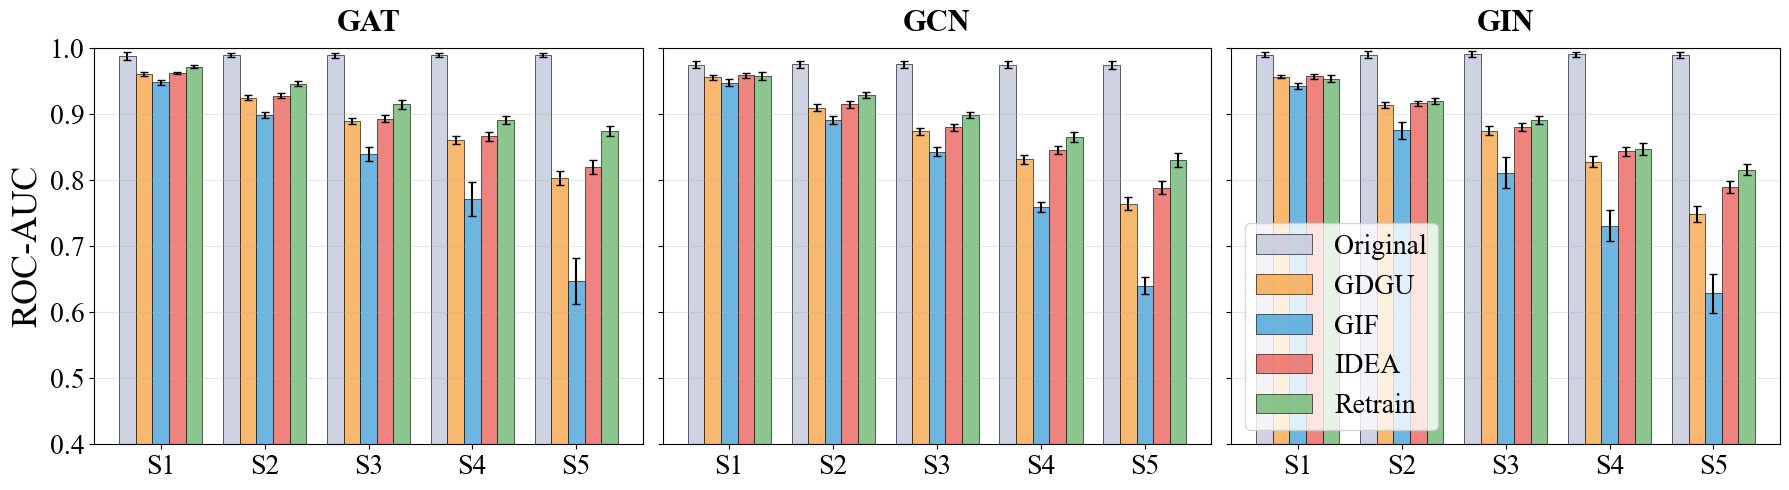

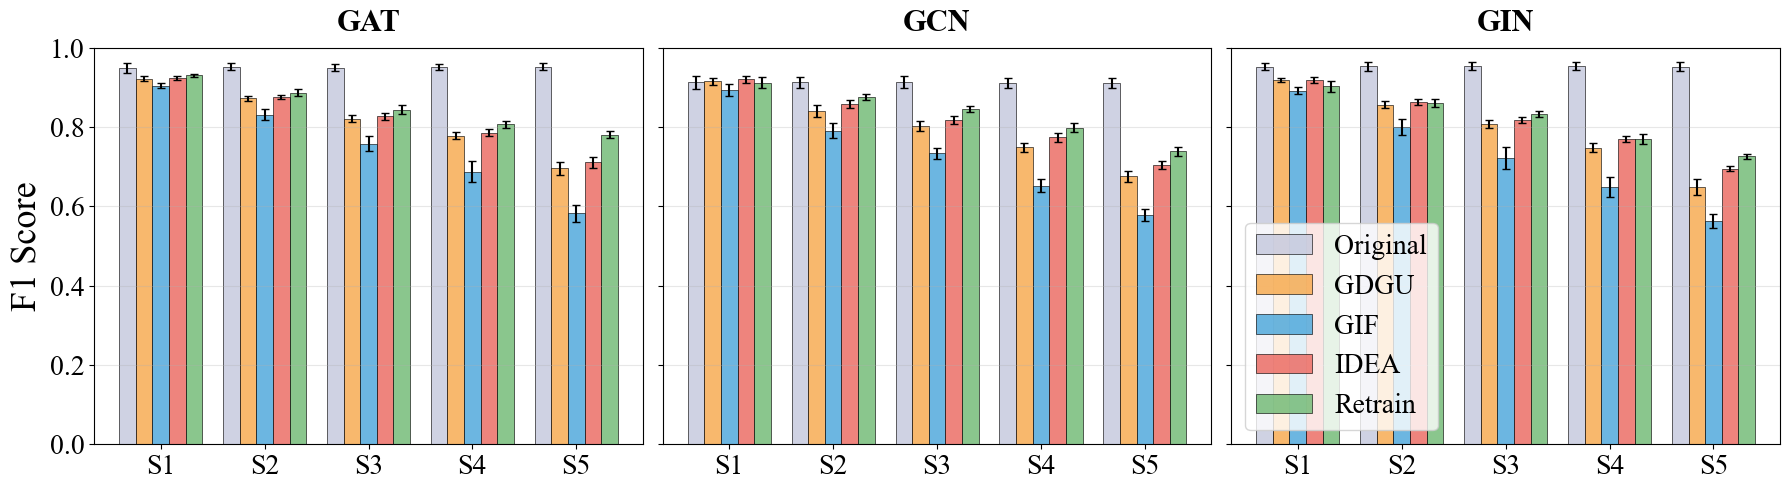

In [3]:
# Cell 4 — Utility: ROC-AUC / F1 Score
plot_metric_bars(df, 'Macro_ROC', 'ROC-AUC', (0.4, 1.0),
                 str(RESULTS_DIR / f'{BUS_SYSTEM}_ROCAUC_comparison.pdf'),
                 scenarios, backbones)
plot_metric_bars(df, 'Macro_F1', 'F1 Score', (0.0, 1.0),
                 str(RESULTS_DIR / f'{BUS_SYSTEM}_F1_comparison.pdf'),
                 scenarios, backbones)

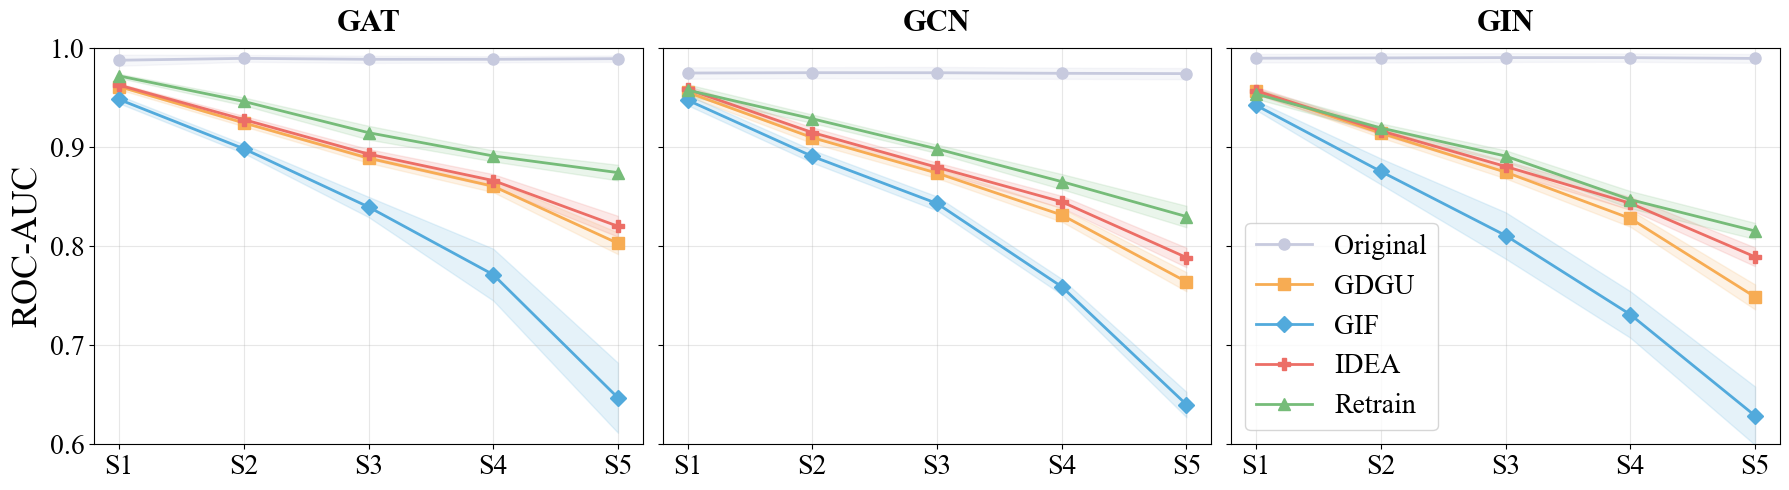

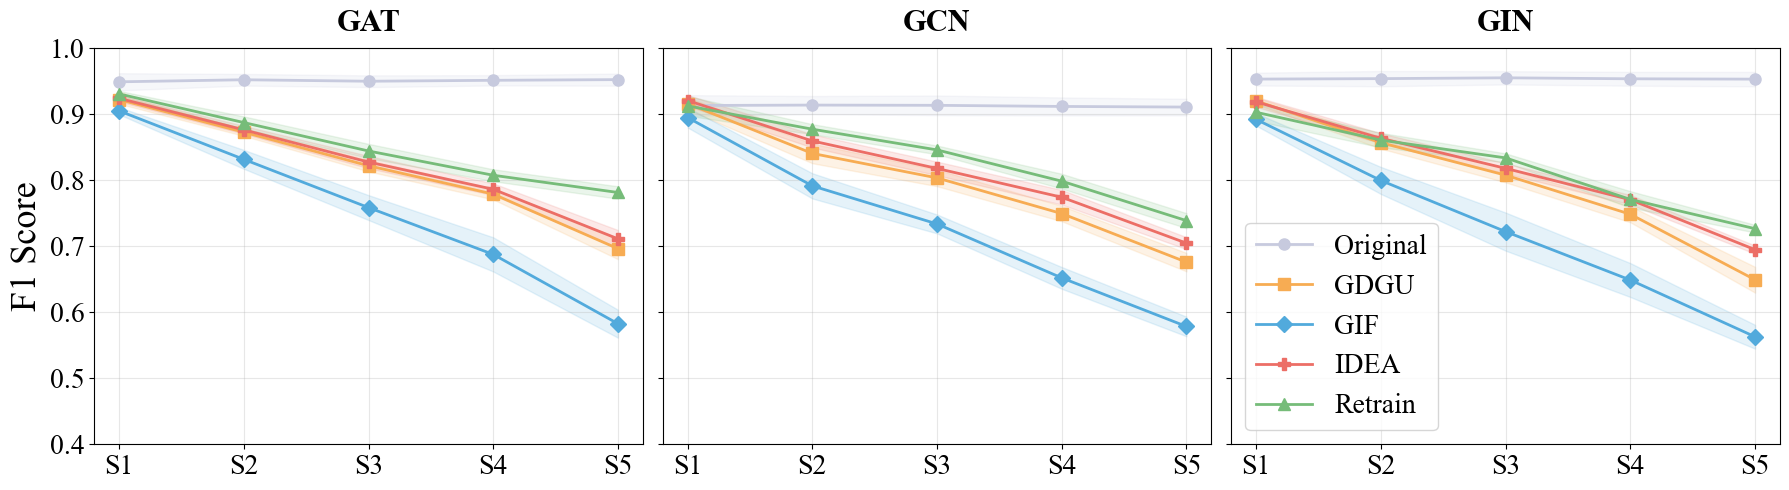

In [4]:
# Cell 4b — Utility trends across cumulative scenarios (line, per backbone)
plot_metric_lines(df, 'Macro_ROC', 'ROC-AUC', (0.6, 1.0),
                  str(RESULTS_DIR / f'{BUS_SYSTEM}_ROCAUC_trend.pdf'),
                  scenarios, backbones, xlabel='')
plot_metric_lines(df, 'Macro_F1', 'F1 Score', (0.4, 1.0),
                  str(RESULTS_DIR / f'{BUS_SYSTEM}_F1_trend.pdf'),
                  scenarios, backbones, xlabel='')

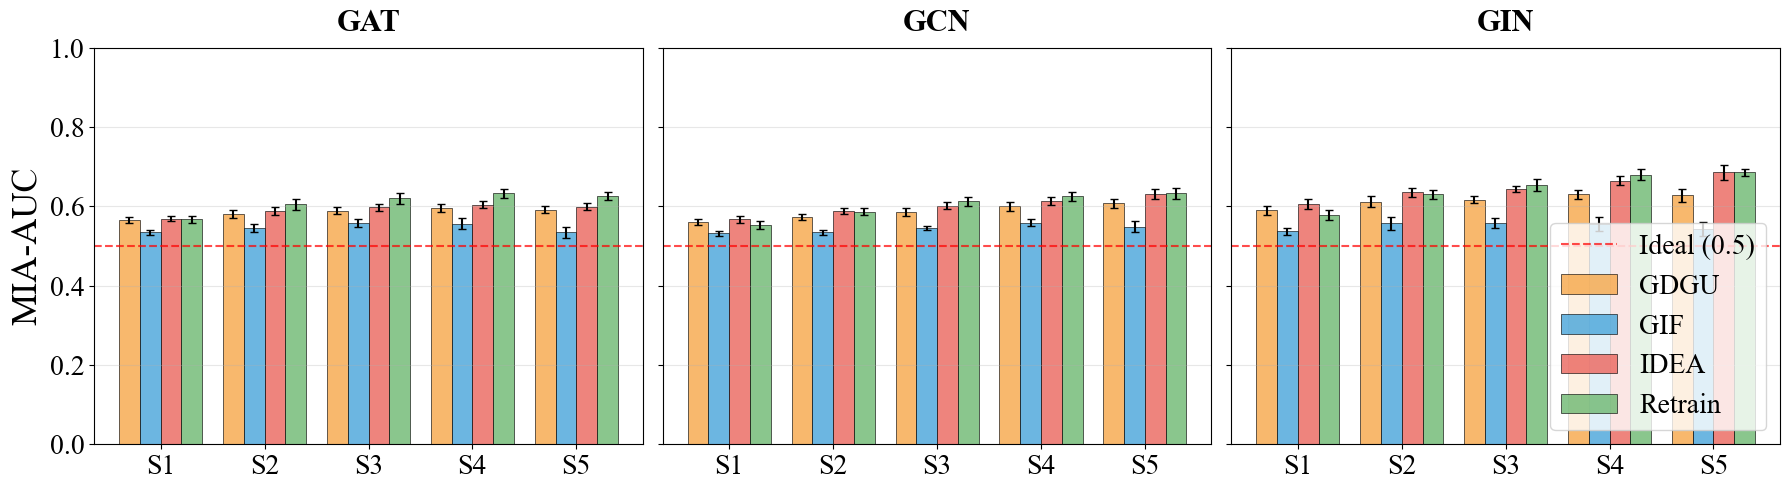

In [5]:
# Cell 8 — MIA-AUC (forgotten EVCS); closer to 0.5 = stronger forgetting
plot_mia_metric(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_MIA_comparison.pdf'),
    scenarios, backbones,
    metric_col='MIA_forget', ylabel='MIA-AUC')

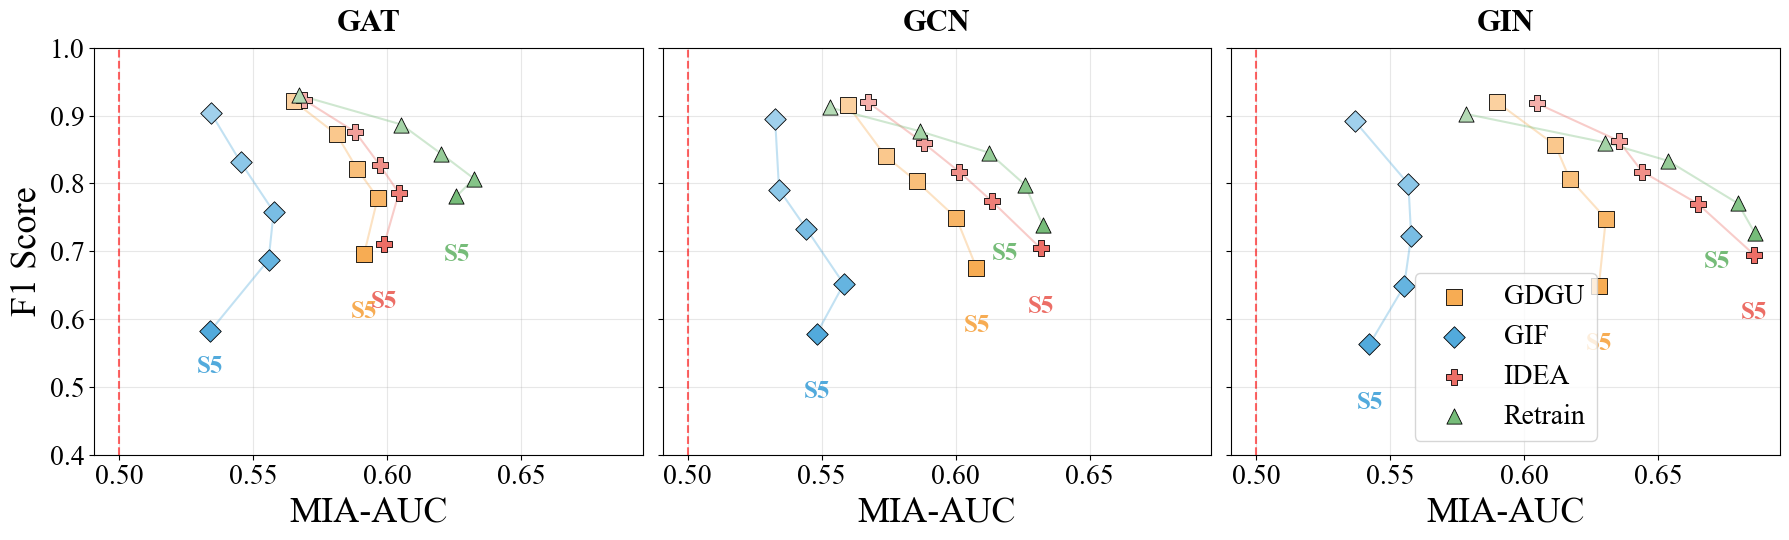

In [6]:
# Cell 8b — Forgetting--reasoning trade-off: F1 Score vs MIA-AUC
# x closer to 0.5 = stronger forgetting; higher y = better localization
plot_f1_vs_mia(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_F1_vs_MIA_tradeoff.pdf'),
    scenarios, backbones)

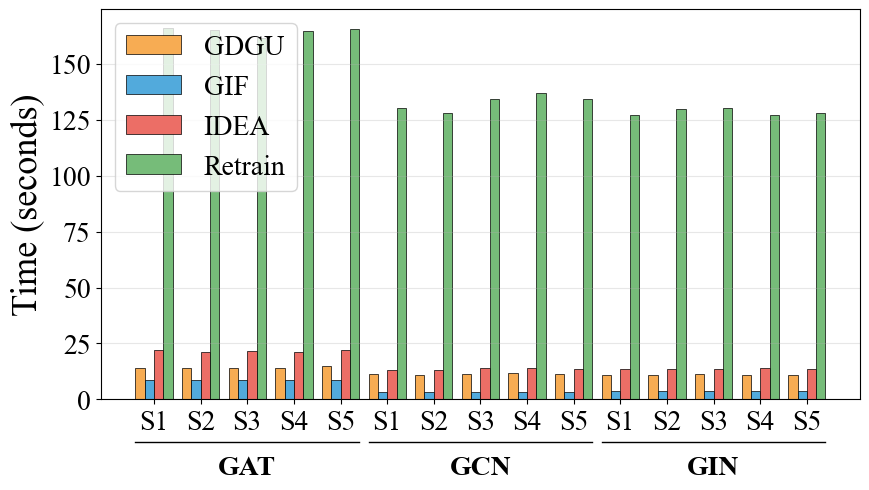

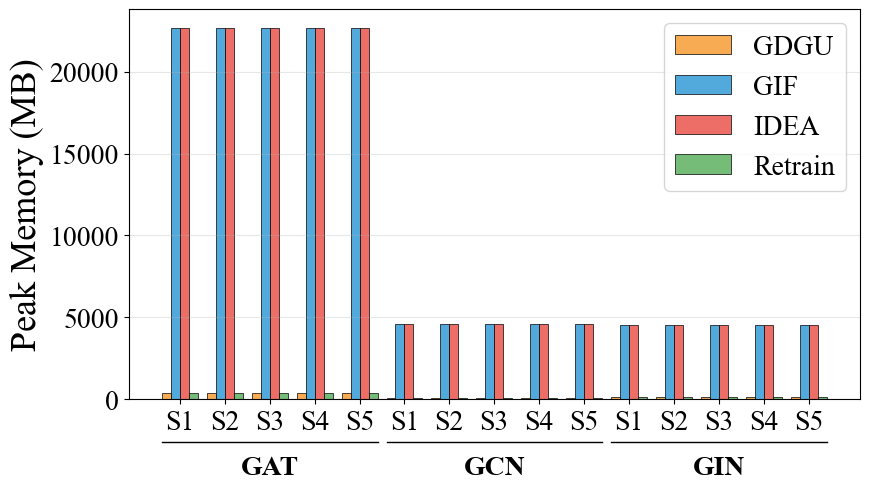

In [7]:
# Cell 10 — Efficiency: time & memory
plot_time_comparison(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Time.pdf'),
    scenarios, backbones)
plot_memory_usage(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Memory.pdf'),
    scenarios, backbones)